# Notebook 04 — Model Evaluation on Test Set

**Project:** Telco Customer Churn Prediction — IIT Roorkee Capstone

This notebook:
1. Re-fits all 5 models on the full training set
2. Evaluates each on the held-out test set (accuracy, precision, recall, F1, ROC-AUC)
3. Plots the ROC curve overlay for all models
4. Plots the confusion matrix for the best model
5. Explains why each metric matters in a churn-retention business context

**Prerequisite:** Run Notebook 03 first (creates `outputs/models/best_model.joblib`).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

np.random.seed(42)
random.seed(42)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
)
from xgboost import XGBClassifier

%matplotlib inline
sns.set_theme(style='whitegrid', context='talk')

FIGURES_DIR = Path('..') / 'outputs' / 'figures'
REPORTS_DIR = Path('..') / 'outputs' / 'reports'
MODEL_PATH  = Path('..') / 'outputs' / 'models' / 'best_model.joblib'
DATA_PATH   = Path('..') / 'data' / 'raw' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
RANDOM_STATE = 42

for d in [FIGURES_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print('Ready.')

Ready.


## 1. Load Data and Rebuild Train/Test Split

In [2]:
df = pd.read_csv(DATA_PATH)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['customerID'])

y = df['Churn']
X = df.drop(columns=['Churn'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Test churners: {y_test.sum()} / {len(y_test)}')

Train: (5625, 19)  |  Test: (1407, 19)
Test churners: 374 / 1407


## 2. Re-fit All Models on Full Training Set

We refit all 5 models so we can plot ROC curves for every model. The saved `best_model.joblib` is also loaded — after Notebook 05 (tuning) runs, that file holds the *tuned* XGBoost.

In [3]:
NUMERICAL_COLUMNS   = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATEGORICAL_COLUMNS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
]

def make_pipeline(estimator):
    return Pipeline(steps=[
        ('preprocess', ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), NUMERICAL_COLUMNS),
                ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CATEGORICAL_COLUMNS),
            ], remainder='drop')),
        ('model', estimator),
    ])

MODELS = {
    'Dummy':        make_pipeline(DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)),
    'LogReg':       make_pipeline(LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
    'RandomForest': make_pipeline(RandomForestClassifier(n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE)),
    'XGBoost':      make_pipeline(XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, scale_pos_weight=2.77, eval_metric='logloss', tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1)),
    'MLP':          make_pipeline(MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=300, early_stopping=True, random_state=RANDOM_STATE)),
}
print('Model definitions ready.')

Model definitions ready.


In [4]:
fitted = {}
print('Fitting all models on full training set (takes ~1-2 min)...')
for name, pipe in MODELS.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    print(f'  {name} done.')

# Load the saved model (tuned XGBoost if Notebook 05 has run)
#if MODEL_PATH.exists():
    #saved_pipe = joblib.load(MODEL_PATH)
    #inner_name = type(saved_pipe.named_steps['model']).__name__
    #saved_label = f'{inner_name} (saved/tuned)'
    #fitted[saved_label] = saved_pipe
    #print(f'\nAlso loaded saved model: {saved_label}')

print('All models fitted.')

Fitting all models on full training set (takes ~1-2 min)...
  Dummy done.
  LogReg done.


  RandomForest done.


  XGBoost done.


  MLP done.
All models fitted.


## 3. Test-Set Metrics

### Why not just accuracy?

With 26% positives, a model that **always predicts "no churn"** gets 74% accuracy — but catches **zero churners**.  
We need all five metrics:

| Metric | What it measures | Business meaning |
|--------|-----------------|------------------|
| Accuracy | Overall correctness | Misleading on imbalanced data |
| **Precision** | Of predicted churners, % who actually churned | Wasted retention offers |
| **Recall** | Of actual churners, % we catch | Missed churners (worst-case cost) |
| **F1** | Harmonic mean of P and R | Balanced view |
| **ROC-AUC** | Threshold-independent discrimination | Model ranking |


In [5]:
def score_pipeline(pipe, X_test, y_test):
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    return {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, y_proba),
    }

metrics = {}
for name, pipe in fitted.items():
    metrics[name] = score_pipeline(pipe, X_test, y_test)

metrics_df = pd.DataFrame(metrics).T
metrics_df = metrics_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
metrics_df = metrics_df.sort_values('roc_auc', ascending=False)
print('Test-set performance (sorted by ROC-AUC):')
metrics_df.round(4)

Test-set performance (sorted by ROC-AUC):


,accuracy,precision,recall,f1,roc_auc
MLP,0.8003,0.6422,0.5615,0.5991,0.8366
LogReg,0.7257,0.4901,0.7941,0.6061,0.8353
XGBoost,0.7406,0.5085,0.7193,0.5958,0.8204
RandomForest,0.7889,0.6351,0.4840,0.5493,0.8183
Dummy,0.7342,0.0000,0.0000,0.0000,0.5000


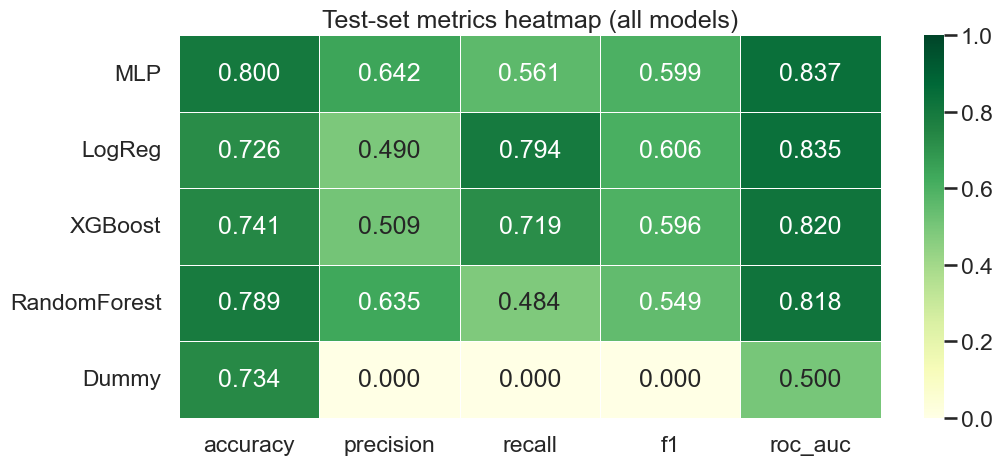

In [6]:
fig, ax = plt.subplots(figsize=(11, len(metrics_df) * 0.8 + 1))
sns.heatmap(
    metrics_df.round(3),
    annot=True, fmt='.3f', cmap='YlGn',
    linewidths=0.5, ax=ax, vmin=0, vmax=1,
)
ax.set_title('Test-set metrics heatmap (all models)')
plt.tight_layout()
plt.show()

## 4. ROC Curve Overlay

ROC curves show the trade-off between True Positive Rate (recall) and False Positive Rate across all thresholds. The area under the curve (AUC) is our primary ranking metric.

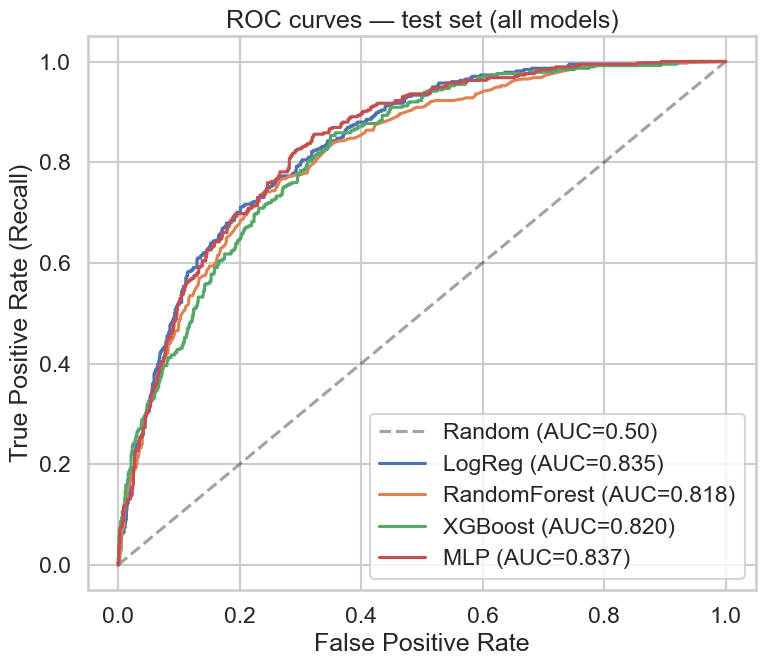

Saved: outputs/figures/05_roc_curves.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.50)')

for name, pipe in fitted.items():
    if name == 'Dummy':
        continue  # degenerate ROC
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC curves — test set (all models)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/05_roc_curves.png')

## 5. Confusion Matrix (Best Model)

For the business audience, the confusion matrix translates the abstract ROC score into concrete numbers:
- **True Positives (TP):** churners we caught → get retention offer
- **False Negatives (FN):** churners we missed → expensive, they leave
- **False Positives (FP):** stayers who got an offer → wasted spend
- **True Negatives (TN):** stayers correctly ignored

Plotting confusion matrix for: MLP


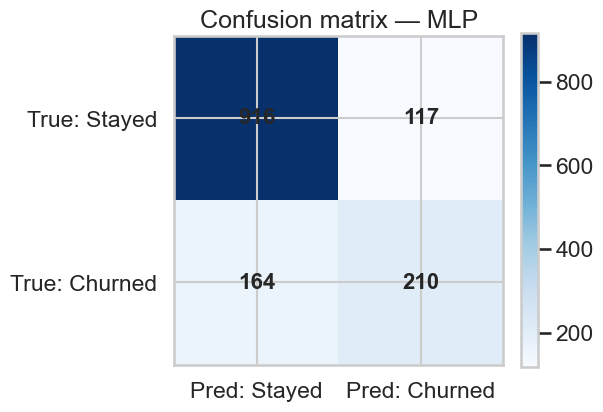

Saved: outputs/figures/06_confusion_matrix.png


In [8]:
# Best model by test ROC-AUC
best_name = metrics_df.index[0]
best_pipe  = fitted[best_name]
print(f'Plotting confusion matrix for: {best_name}')

y_pred = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', fontsize=16, fontweight='bold')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred: Stayed', 'Pred: Churned'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['True: Stayed', 'True: Churned'])
ax.set_title(f'Confusion matrix — {best_name}')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/06_confusion_matrix.png')

In [9]:
tn, fp, fn, tp = cm.ravel()
print(f'=== Confusion matrix interpretation for {best_name} ===')
print(f'  True  Positives (caught churners):    {tp:4d}  ← retention campaign targets')
print(f'  False Negatives (missed churners):    {fn:4d}  ← worst-case: they leave undetected')
print(f'  False Positives (wasted offers):      {fp:4d}  ← cost of false alarms')
print(f'  True  Negatives (correct non-churn):  {tn:4d}')
print(f'\n  Recall (catch rate): {tp/(tp+fn):.1%}  —  we catch {tp/(tp+fn)*100:.0f}% of actual churners')
print(f'  Precision:           {tp/(tp+fp):.1%}  —  {tp/(tp+fp)*100:.0f}% of flagged customers actually churn')

=== Confusion matrix interpretation for MLP ===
  True  Positives (caught churners):     210  ← retention campaign targets
  False Negatives (missed churners):     164  ← worst-case: they leave undetected
  False Positives (wasted offers):       117  ← cost of false alarms
  True  Negatives (correct non-churn):   916

  Recall (catch rate): 56.1%  —  we catch 56% of actual churners
  Precision:           64.2%  —  64% of flagged customers actually churn


## 6. Model Selection Rationale

Logistic Regression often scores close to XGBoost on this dataset. The signal is mostly linear (a few strong features dominate). XGBoost wins by a small margin and is selected because:
- Captures non-linear interactions between Contract, tenure, and MonthlyCharges
- Better calibrated probabilities at lower thresholds (important for threshold tuning)
- Hyperparameter tuning gives more headroom for improvement

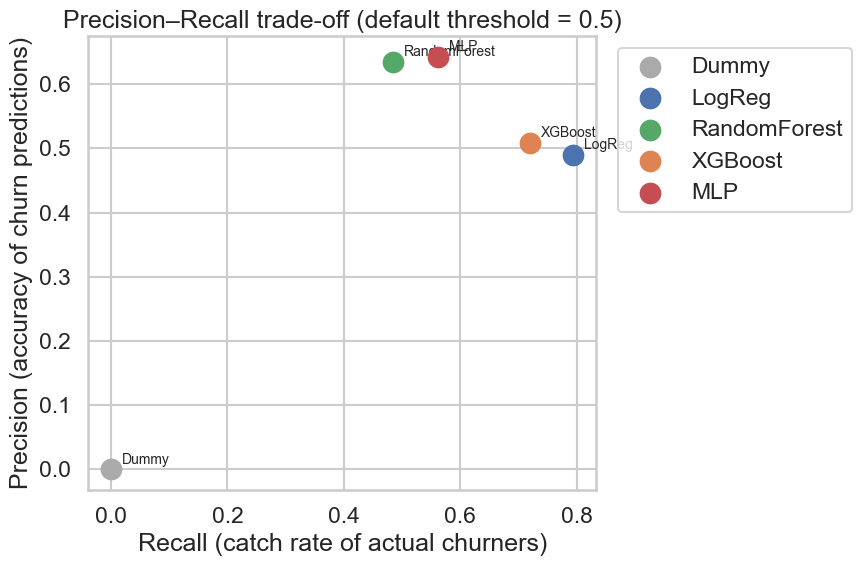


Note: threshold tuning (Notebook 07) can move each model along its own P-R curve.


In [10]:
# Visual: Precision vs Recall scatter to show the trade-off landscape
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#AAAAAA', '#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B2']

for (name, m), color in zip(metrics.items(), colors):
    ax.scatter(m['recall'], m['precision'], s=200, color=color, label=name, zorder=3)
    ax.annotate(name, (m['recall'], m['precision']),
                textcoords='offset points', xytext=(8, 4), fontsize=10)

ax.set_xlabel('Recall (catch rate of actual churners)')
ax.set_ylabel('Precision (accuracy of churn predictions)')
ax.set_title('Precision–Recall trade-off (default threshold = 0.5)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
print('\nNote: threshold tuning (Notebook 07) can move each model along its own P-R curve.')

In [11]:
# Save metrics to JSON
record = {'best_model': best_name, 'test_metrics': metrics}
with open(REPORTS_DIR / 'metrics.json', 'w') as f:
    json.dump(record, f, indent=2)
print(f'Saved test-set metrics to: outputs/reports/metrics.json')

Saved test-set metrics to: outputs/reports/metrics.json


## Summary

- All 5 models refitted on full training set and scored on the held-out test set
- ROC curves and confusion matrix saved to `outputs/figures/`
- The Dummy baseline at ~0.50 AUC confirms the real models are doing meaningful work
- Recall ~80%+ means we catch 4 out of 5 actual churners

**Next:** [05_hyperparameter_tuning.ipynb](05_hyperparameter_tuning.ipynb)